# Results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
results_pth = "/Users/mayajanvier/jax-phynity/data/sanity_checks/complete_physics4/model_1.008e+00..json"
results = pd.read_json(results_pth).T
results

,states,pred,loss_val,loss_op
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.687880039215088, -2....",0.023147,0.0
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.405747413635254, 1.69102...",0.002726,0.0
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.658685445785522, -1.9...",0.004142,0.0
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.621750831604003, -1....",0.039594,0.0
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.426576972007751, 1.1514...",0.002743,0.0
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.480870962142944, 2.8691...",0.012223,0.0
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.6037119626998901, -1....",0.003548,0.0
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.710173368453979, 2.2700...",0.021869,0.0
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.542604684829712, -2....",0.054782,0.0
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.495648145675659, -1.6...",0.002041,0.0


In [2]:
# physics only 
import jax.numpy as jnp
from networks import DampedPendulumParamPDE
from forecasters import Forecaster
model_phy = DampedPendulumParamPDE(is_complete=True, real_params={"omega0_square": 2*jnp.pi/12, "alpha":0.2})
net_phy = Forecaster(model_phy=model_phy, model_aug=None, is_augmented=False, is_phy="complete", method="RK4")


In [3]:
import jax.numpy as jnp 
def plot_trajectory(index):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    y0 = np.array(results["states"][index])[:,0]
    print(y0)
    phy_out = net_phy(np.array([results["states"][index]]), jnp.arange(0,20,0.5)) 
    print(phy_out.shape)

    ax[0].set_title("Position") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="black")
    ax[0].plot(np.array(phy_out[0,0,:]), label="eq_org", color="red")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="blue")
    ax[0].legend()

    ax[1].set_title("Velocity")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="black")
    ax[1].plot(np.array(phy_out[0,1,:]), label="eq_org", color="red")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="blue")
    ax[1].legend()
    plt.show()


[-0.02109816  1.44624829]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


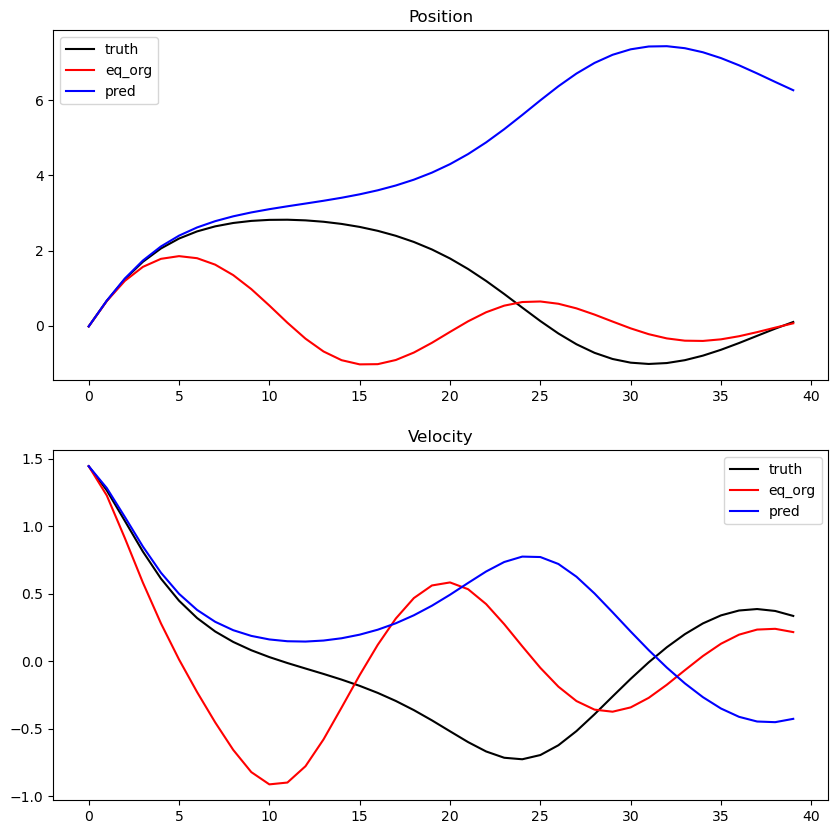

In [4]:
plot_trajectory(12)

[0.52782559 1.32926977]
(1, 2, 40)


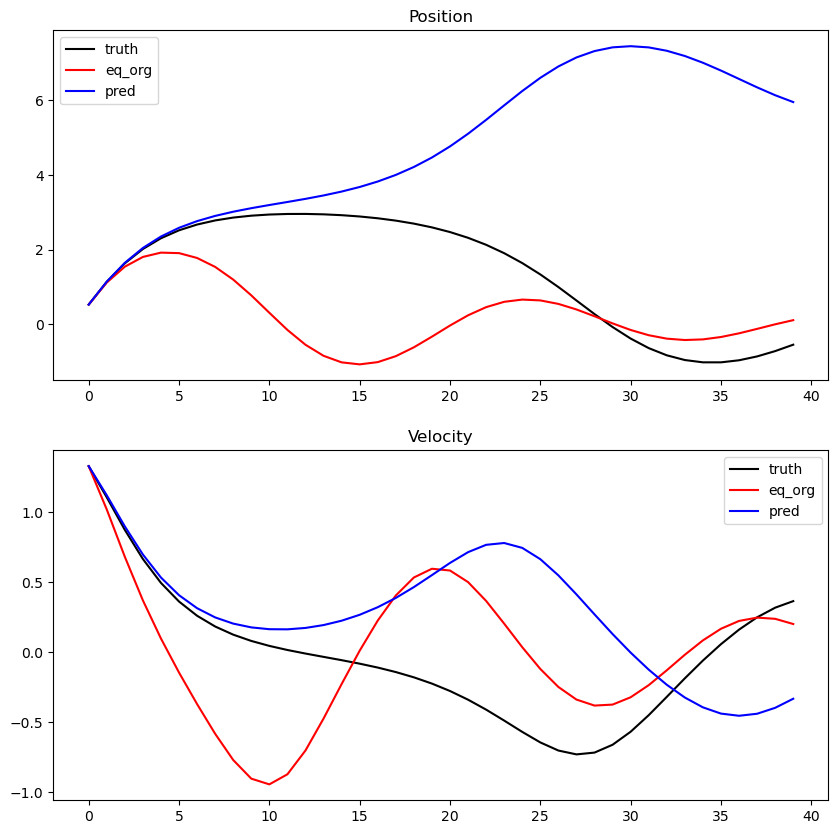

In [5]:
plot_trajectory(22)

[-1.34345663  0.41287747]
(1, 2, 40)


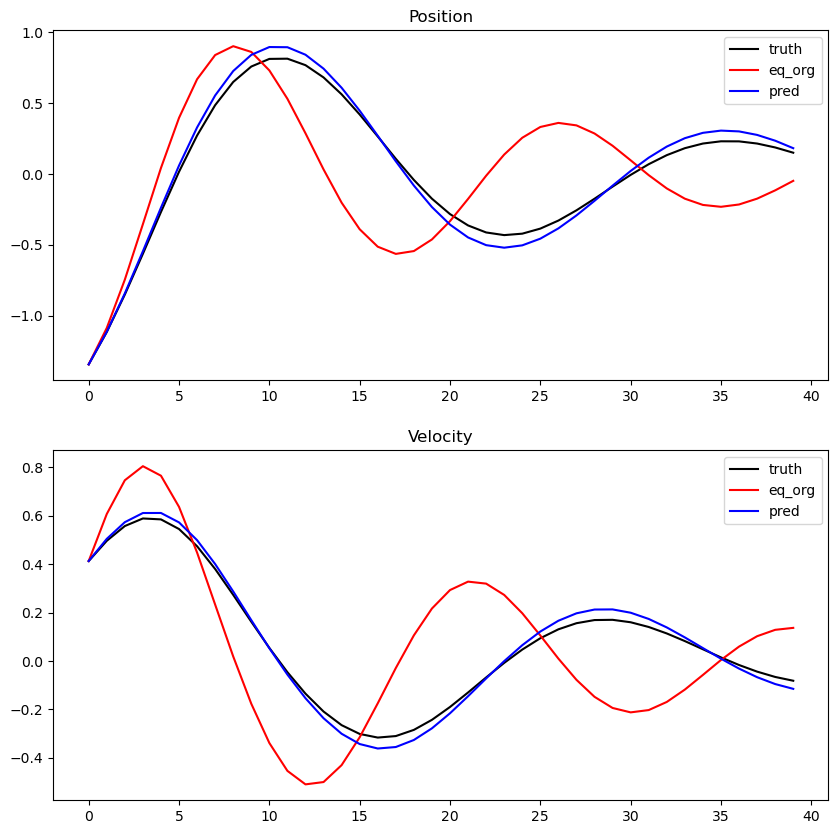

In [6]:
plot_trajectory(24)

In [10]:
import matplotlib.pyplot as plt
results_pth = "/Users/mayajanvier/jax-phynity/data/sanity_checks/incomplete_aug3/model_1.508e+00..json"
results = pd.read_json(results_pth).T
results

,states,pred,loss_val,loss_op
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.626970410346984, -2....",0.211602,0.002573
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.424392223358154, 1.74875...",0.378943,0.001084
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.628757238388061, -1.9...",0.237589,0.001309
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.6408729553222651, -1...",0.143368,0.002837
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.430660128593444, 1.1600...",0.170913,0.000969
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.480446577072143, 2.8727...",0.112306,0.000886
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.574680805206298, -1.8...",0.24868,0.001296
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.737329006195068, 2.3514...",0.099819,0.000981
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.492254257202148, -2....",0.204859,0.002653
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.48915433883667, -1.61...",0.217697,0.001045


In [11]:
model_phy = DampedPendulumParamPDE(is_complete=False, real_params={"omega0_square": 2*jnp.pi/12, "alpha":0.2})
net_phy = Forecaster(model_phy=model_phy, model_aug=None, is_augmented=False, is_phy="complete", method="RK4")

In [12]:
import jax.numpy as jnp 
def plot_trajectory(index):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    y0 = np.array(results["states"][index])[:,0]
    print(y0)
    phy_out = net_phy(np.array([results["states"][index]]), jnp.arange(0,20,0.5)) 
    print(phy_out.shape)

    ax[0].set_title("Position") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="black")
    ax[0].plot(np.array(phy_out[0,0,:]), label="eq_org", color="red")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="blue")
    ax[0].legend()

    ax[1].set_title("Velocity")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="black")
    ax[1].plot(np.array(phy_out[0,1,:]), label="eq_org", color="red")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="blue")
    ax[1].legend()
    plt.show()


[-0.02109816  1.44624829]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


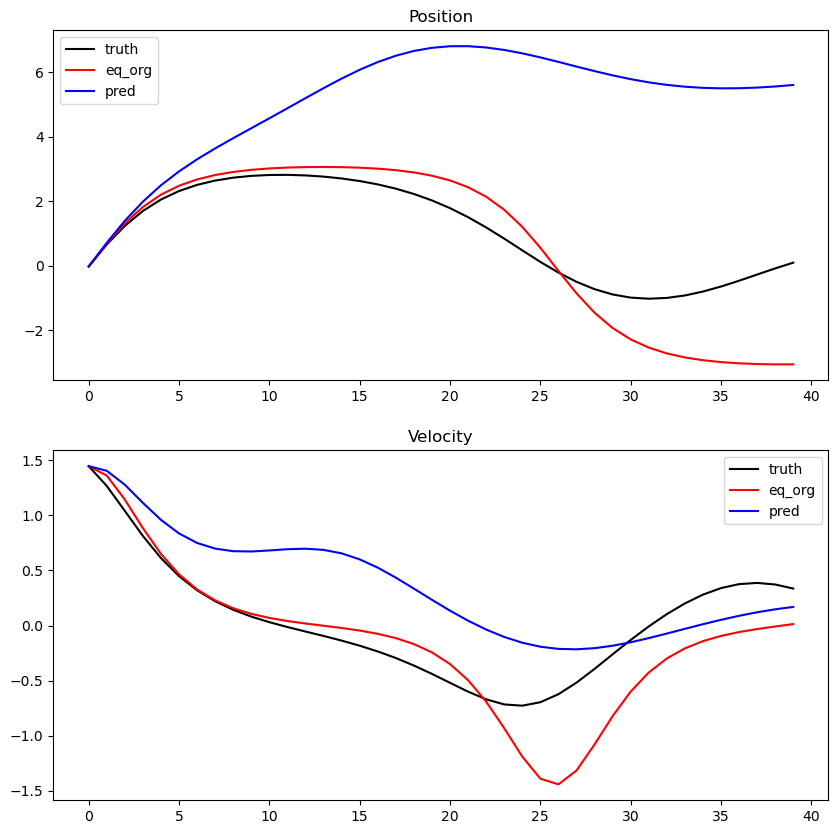

In [13]:
plot_trajectory(12)

[0.52782559 1.32926977]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


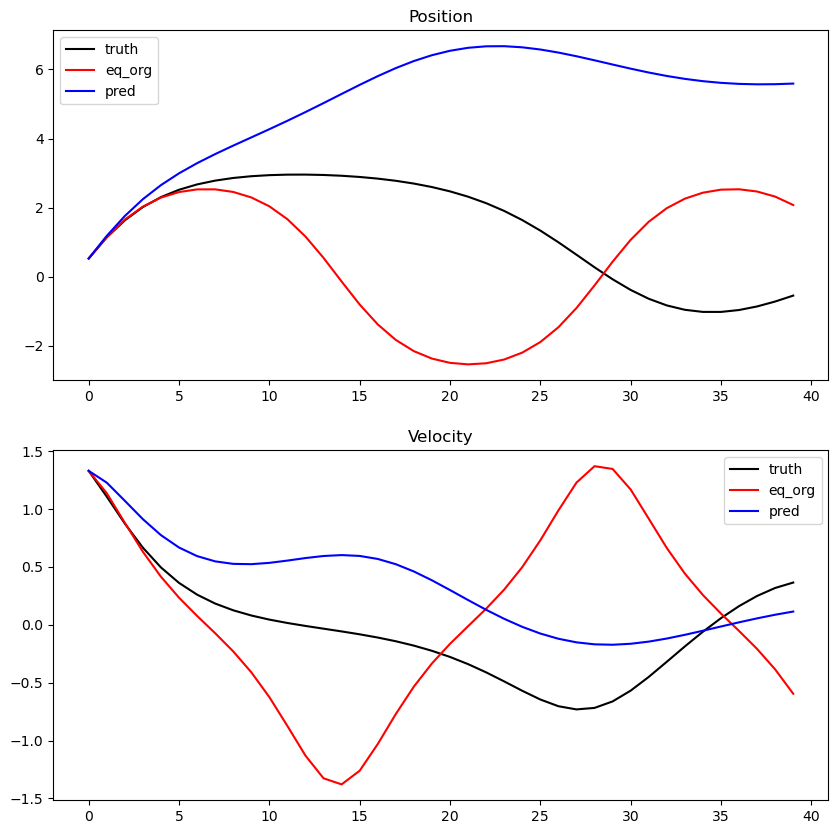

In [14]:
plot_trajectory(22)

[-1.34345663  0.41287747]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


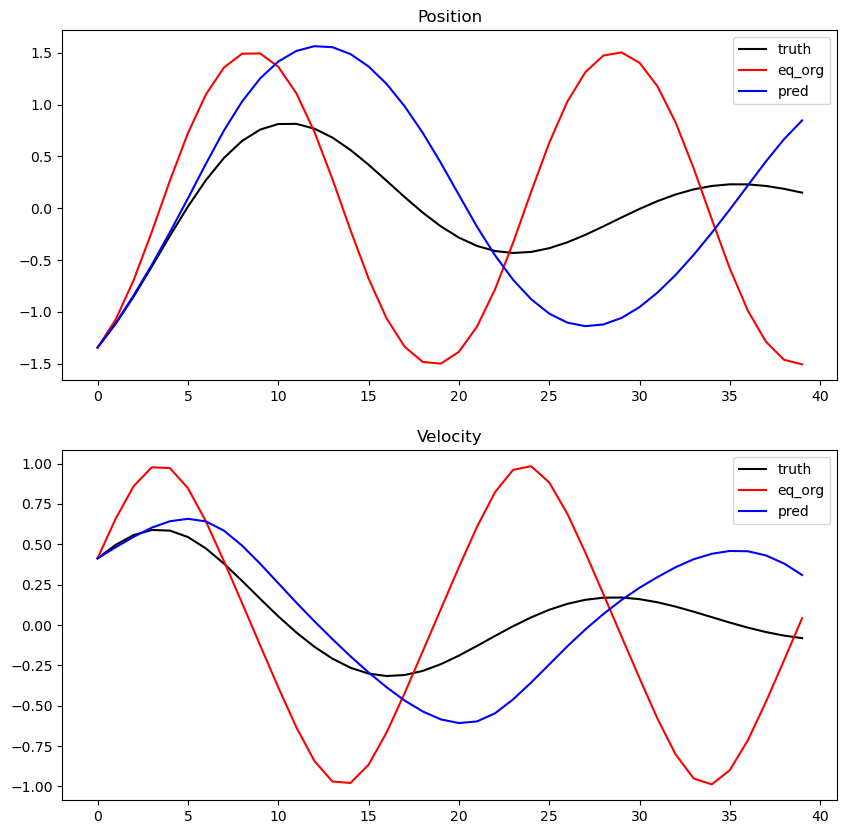

In [15]:
plot_trajectory(24)

# None aug5


In [16]:
results_pth = "/Users/mayajanvier/jax-phynity/data/sanity_checks/none_aug5/model_1.006e+00..json"
results = pd.read_json(results_pth).T
results

,states,pred,loss_val,loss_op
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.6181092262268062, -2...",0.18581,0.0
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.340431213378906, 1.58105...",0.101088,0.0
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.637307405471801, -1.9...",0.098446,0.0
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.559412360191345, -1....",0.156073,0.0
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.369356155395507, 1.0821...",0.047644,0.0
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.45348310470581, 2.84081...",0.09176,0.0
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.582802057266235, -1.8...",0.092699,0.0
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.651341915130615, 2.2217...",0.062379,0.0
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.469146966934204, -2....",0.25517,0.0
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.483283877372741, -1.5...",0.04442,0.0


In [17]:
model_phy = DampedPendulumParamPDE(is_complete=True, real_params={"omega0_square": 2*jnp.pi/12, "alpha":0.2})
net_phy = Forecaster(model_phy=model_phy, model_aug=None, is_augmented=False, is_phy="complete", method="RK4")

In [18]:
def plot_trajectory(index):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    y0 = np.array(results["states"][index])[:,0]
    print(y0)
    phy_out = net_phy(np.array([results["states"][index]]), jnp.arange(0,20,0.5)) 
    print(phy_out.shape)

    ax[0].set_title("Position") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="black")
    ax[0].plot(np.array(phy_out[0,0,:]), label="eq_org", color="red")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="blue")
    ax[0].legend()

    ax[1].set_title("Velocity")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="black")
    ax[1].plot(np.array(phy_out[0,1,:]), label="eq_org", color="red")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="blue")
    ax[1].legend()
    plt.show()

[-0.02109816  1.44624829]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


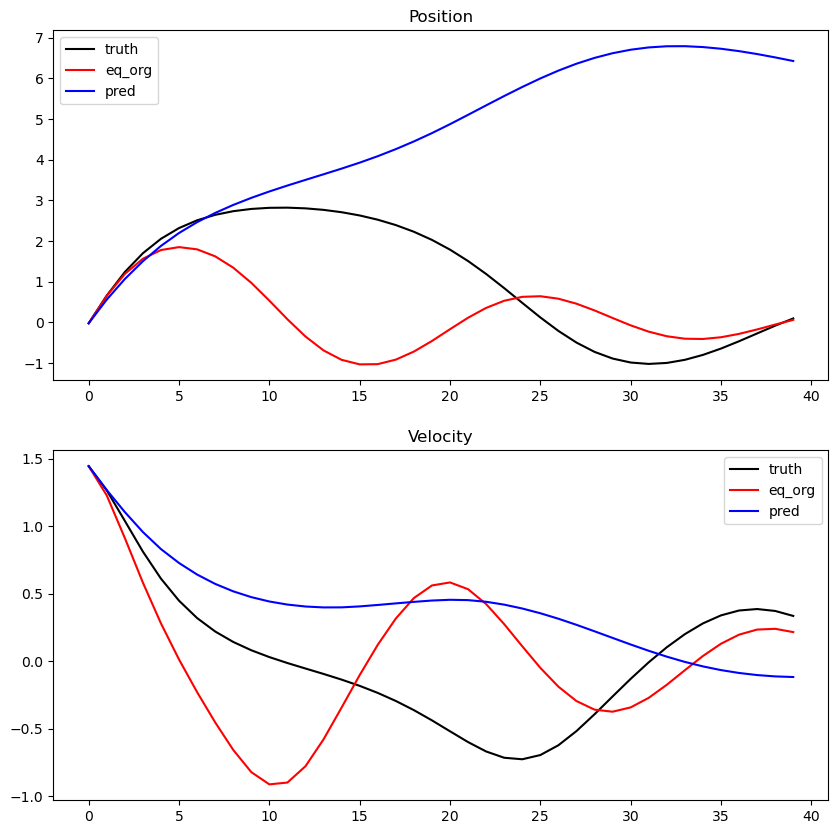

In [19]:
plot_trajectory(12)

[-1.34345663  0.41287747]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


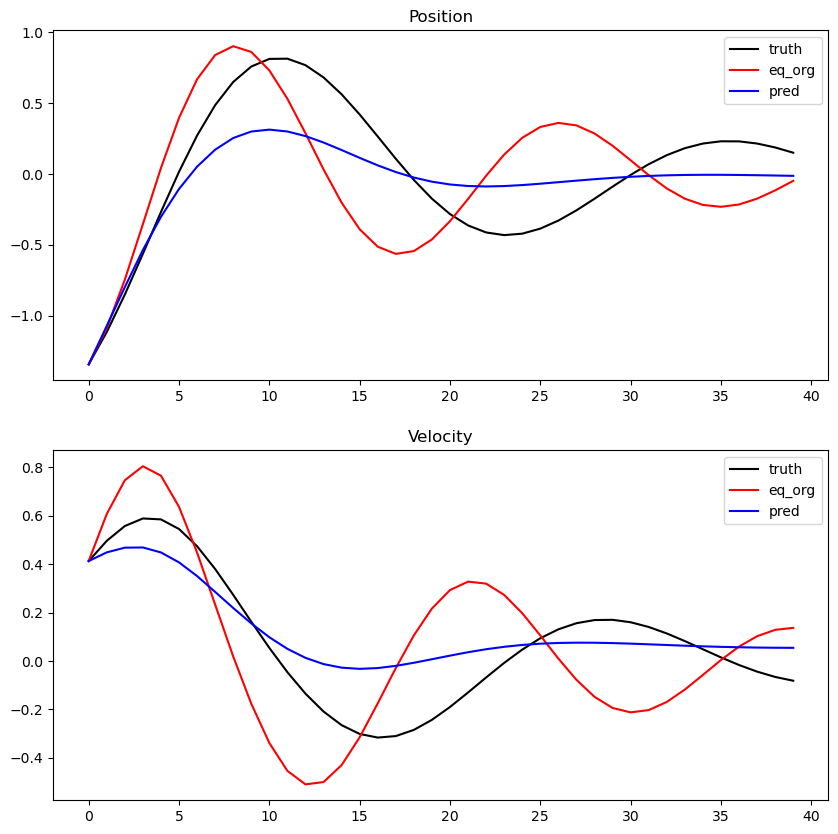

In [20]:
plot_trajectory(24)

# none aug6 

In [22]:
results_pth = "/Users/mayajanvier/jax-phynity/data/sanity_checks/none_aug6/model_1.784e+00..json"
results = pd.read_json(results_pth).T
results

,states,pred,loss_val,loss_op
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.545371651649475, -2....",0.423295,0.0
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.3244702816009521, 1.6016...",1.66484,0.0
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.612063407897949, -1.9...",1.102503,0.0
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.47063967585563604, -...",0.314862,0.0
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.383215904235839, 1.1161...",0.088045,0.0
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.423594713211059, 2.8058...",0.327988,0.0
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.557781219482421, -1.8...",1.027345,0.0
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.577638626098632, 2.1117...",0.171073,0.0
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.380985379219055, -2....",0.483737,0.0
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.486307859420776, -1.6...",0.317323,0.0


In [23]:
def plot_trajectory(index):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    y0 = np.array(results["states"][index])[:,0]
    print(y0)
    phy_out = net_phy(np.array([results["states"][index]]), jnp.arange(0,20,0.5)) 
    print(phy_out.shape)

    ax[0].set_title("Position") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="black")
    ax[0].plot(np.array(phy_out[0,0,:]), label="eq_org", color="red")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="blue")
    ax[0].legend()

    ax[1].set_title("Velocity")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="black")
    ax[1].plot(np.array(phy_out[0,1,:]), label="eq_org", color="red")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="blue")
    ax[1].legend()
    plt.show()

[-0.02109816  1.44624829]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


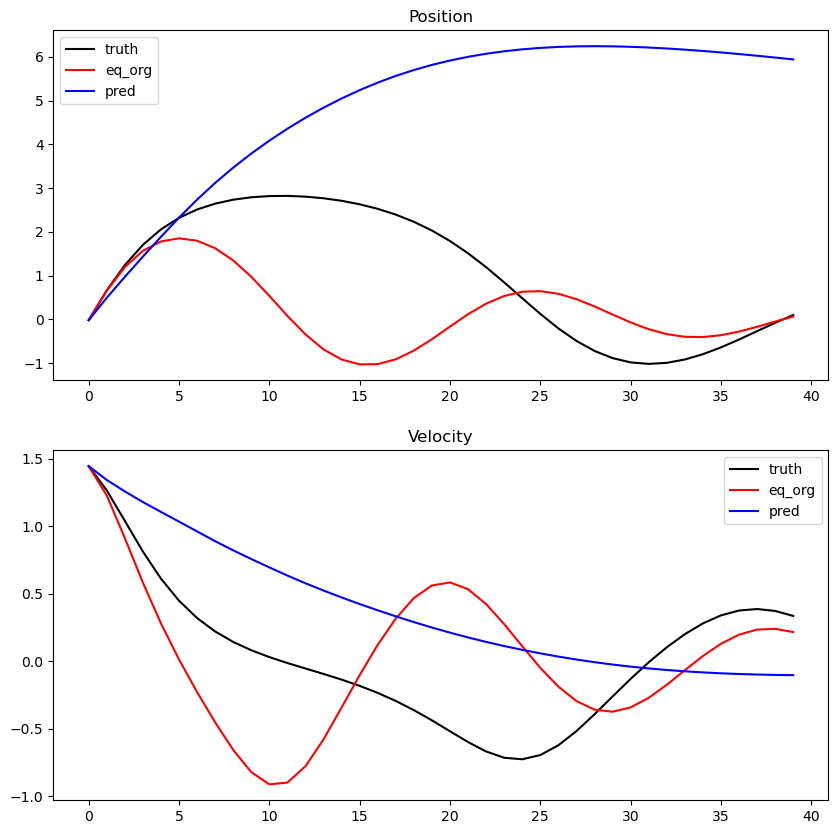

In [24]:
plot_trajectory(12)

[-1.34345663  0.41287747]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


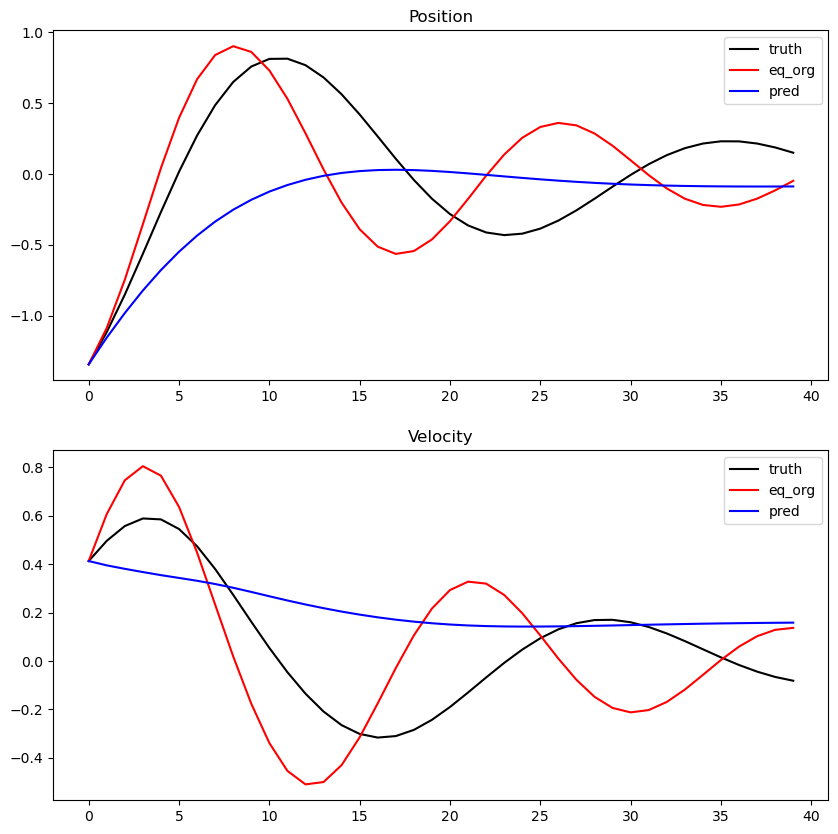

In [25]:
plot_trajectory(24)